In [1]:
import numpy as np
from matplotlib import pyplot as plt
from identify_substeps_hmm import *
from scipy.optimize import curve_fit
import os

In [4]:
out_file_name = "TRY_1dwell"
out_file_path = "regularRotRegion_1"
short_dwell_cutoff = 0.0
weights = [1.0, 5.0]#, 10.0, 20.0, 50.0, 100.0]

#os.mkdir(".//%s"%out_file_path)

In [5]:
'''
HMM_init = HiddenMarkovModel(vecAsyState = [0.0, 30.0],
                             vecEmitStd = [10.0, 10.0],
                             matTransProb = np.ones((6, 6))/6.0)
'''

HMM_init = HiddenMarkovModel(vecAsyState = [0.0],
                             vecEmitStd = [10.0],
                             matTransProb = np.ones((3, 3))/3.0)



analyzeTrajectory(outFileName = out_file_name, outFilePath = out_file_path, HMM_init = HMM_init,
                  recFileNames = ["F1-ATPase_time=6.20e+01,initState=549,index=%d"%k for k in range(1)],
                  
                  preprocess = True,
                  fps_exp = 1e4,
                  std_cutoff = 240.0,
                  
                  run_BW = True,
                  BW_lineIndex = 3,
                  N_iter = 20, errorbar = 1.0,
                  
                  run_viterbi = True,
                  weights = weights,
                  
                  post_viterbi = False,
                  short_dwell_cutoff = short_dwell_cutoff)

In [6]:
def readInferredAngle(ax, filePath, fileName):
    
    t_camera, vec_obs_reloc, inferred_angle, assigned_state = [], [], [], []
    
    #fig, ax = plt.subplots(figsize = (5, 3))
    
    ax.set_ylabel("Revolutions")
    ax.set_xlabel("Time (ms)" )
    ax.set_xticks(np.linspace(0, 300e-3, 4))
    ax.set_xticklabels(["%.0f"%x for x in np.linspace(0, 300, 4)])
    ax.set_xlim(0, 300e-3)
    
    ax.set_yticks(np.arange(0, 9.1, 3)*120)
    ax.set_yticklabels(["0", "1", "2", "3"])
    ax.set_ylim(0, 9*120+80)
    ax.grid(axis = "y", c = "black", lw = 1)
    
    for each in np.arange(0, 9.1, 1)*120:
        ax.axhline(y = each, c = "black", lw = 0.6)
        ax.axhline(y = each - 40, c = "lightgrey", lw=0.6)
    
    
    with open(".//%s//%s.traj.csv"%(filePath, fileName), "r") as file:
        
        line = file.readline()
        
        while line:
            
            if line[0] == "T":
                
                if len(t_camera) >= 1:
                    
                    if t_camera[0] >= 0. and t_camera[0] <= 1.:
                    
                        ax.plot(np.array(t_camera) - t_camera[0], np.array(vec_obs_reloc) - vec_obs_reloc[0], color = "grey", lw = 0.5)
                        ax.plot(np.array(t_camera) - t_camera[0], np.array(inferred_angle) - vec_obs_reloc[0], color = "darkred", lw = 0.5)
                        break
                    
                    t_camera, vec_obs_reloc, inferred_angle, assigned_state = [], [], [], []
                
            else:
            
                line = line.split(",")
                t_camera.append(float(line[0]))
                vec_obs_reloc.append(float(line[1]))
                inferred_angle.append(float(line[2]))
                assigned_state.append(int(line[3]))
            
            line = file.readline()

    ax.plot(np.array(t_camera) - t_camera[0], np.array(vec_obs_reloc) - vec_obs_reloc[0], color = "grey", lw = 0.5)
    ax.plot(np.array(t_camera) - t_camera[0], np.array(inferred_angle) - vec_obs_reloc[0], color = "darkred", lw = 0.5)
    
    #plt.tight_layout()
    #plt.savefig(".//%s//%s_w=%.1e_trajectory.png"%(filePath, fileName, w), dpi = 500)
    #plt.show()
    
    return 0

In [10]:
class LifetimeDistribution:
    
    def __init__(self):
        pass
    
    def singleExponential(self, t, k, c):
        return np.exp(-k*t)*c

    def singleExponential_cdf(self, t, k, c):
        return (1.0 - np.exp(-k*t))*c

    def doubleExponential(self, t, k1, k2, c):
        return c*(np.exp(-k2*t)-np.exp(-k1*t))
        
    def doubleExponential_cdf(self, t, k1, k2, c):
        return c*((1.0 - np.exp(-k2*t))/k2 - (1.0 - np.exp(-k1*t))/k1)
    
    

class LifetimeAnalysis(LifetimeDistribution):
    
    
    def plotDwellDistribution(self, ax, bins, lifetime, color):
        
        reprVal = (bins[:-1]+bins[1:])/2
        
        n, _ = np.histogram(lifetime, bins = bins)
        
        if sum(n) != 0:
            n_cumsum = np.cumsum(n)/sum(n)
        else:
            n_cumsum = np.cumsum(n)

        ax.bar(reprVal, n, width = reprVal[1] - reprVal[0], color="white", edgecolor=color, lw = 0.6)
        print("Fit distribution")
        self.plotFitCurve(ax, reprVal, n, self.doubleExponential, p0=[], color = "violet")
        #self.plotFitCurve(ax, reprVal, n, self.singleExponential, p0=[])
        
        #ax_twin = ax.twinx()
        #ax_twin.plot(reprVal, n_cumsum, color=color, lw=2)
        #print("Fit cumulative distribution")
        #self.plotFitCurve(ax_twin, reprVal, n_cumsum, self.doubleExponential_cdf, p0=[80.0, 20.0, 1.0], color = "violet")
        #self.plotFitCurve(ax_twin, reprVal, n_cumsum, self.singleExponential_cdf, p0=[])
        
        ax.set_xlabel("Lifetime (ms)", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.set_yticks([0, 1000])
        ax.set_yticklabels(["0", "$10^3$"], fontsize=8)
        #ax.set_ylim(0, 1800)
        
        ax.set_xlim(0.0, 0.12)
        ax.set_xticks(np.linspace(0.0, 0.1, 3))
        ax.set_xticklabels(["%.0f"%x for x in np.linspace(0.0, 0.1, 3)*1000], fontsize=8)
        
        #ax_twin.set_ylabel("Probability", fontsize=9)
        #ax_twin.set_ylim(-0.05, 1.05)
        #ax_twin.set_yticks([])#np.linspace(0.0, 1.0, 2))
        #ax_twin.set_yticklabels(["%.1f"%x for x in np.linspace(0.0, 1.0, 2)], fontsize=8)
        
        return reprVal, n, n_cumsum
    
    
    def plotFitCurve(self, ax, t, p, func, p0, color = "royalblue"):
        
        try:
            if p0 != []:
                popt, pcov = curve_fit(func, t, p, p0 = p0)
            else:
                popt, pcov = curve_fit(func, t, p)
                
            p_fit = func(t, *popt)
            p_aver = np.average(p)
            r_sq = 1 - np.dot(p_fit - p, p_fit - p)/np.dot(p_aver - p, p_aver - p)
        
            print(["%.2e"%x for x in popt], ["%.2e"%x for x in np.sqrt(np.diag(pcov))], "%.4f"%r_sq)
        
            ax.plot(t, p_fit, ls = ":", dash_capstyle="round", c = color, lw=1.5)
        
            return popt

        except RuntimeError:
            
            print("Curve fit failed!")

            return 0
    
    
    def __call__(self, filePath, fileName_lifetime, fileName_infer, N_dwell):
        
        lifetime = FileOperation().readRecFile_lifetime(filePath, fileName_lifetime, N_dwell)

        W = 17.18/2.54
        fig, ax = plt.subplots(1, 2, figsize = (W/2, W/4))
        plt.subplots_adjust(wspace=0.05, left=0.2, right=0.99, bottom=0.5, top=0.98)
        
        bins = np.arange(0.0, 0.5+1/10000, 0.002)
        
        repr_val, n1, n1_cusum = self.plotDwellDistribution(ax[0], bins, lifetime[0]+lifetime[1]+lifetime[2], 
                                                            color="cornflowerblue")
        #_, n2, n2_cusum = self.plotDwellDistribution(ax[1], bins, lifetime[1]+lifetime[3]+lifetime[5])
        print(sum(n1))
        
        #ax[0].set_xlabel("")
        #ax[0].set_xticklabels([])
        
        #readInferredAngle(ax[2], filePath, fileName_infer)

        ax[1].set_visible(False)
        
        plt.savefig(".//%s//%s_lifetime.png"%(filePath, fileName_lifetime), dpi = 500, transparent=True)
        plt.show()
        plt.close()

analyzeTrajectory(outFileName = out_file_name, outFilePath = out_file_path, HMM_init = HMM_init,
                  recFileNames = ["F1-ATPase_time=6.20e+01,initState=549,index=%d"%k for k in range(1, 10)],
                  
                  preprocess = False,
                  fps_exp = 1e4,
                  std_cutoff = 240.0,
                  
                  run_BW = False,
                  BW_lineIndex = 4,
                  N_iter = 20, errorbar = 1.0,
                  
                  run_viterbi = True,
                  weights = weights,
                  
                  post_viterbi = False,
                  short_dwell_cutoff = short_dwell_cutoff)

Fit distribution
['3.83e+02', '4.19e+01', '2.42e+03'] ['1.22e+01', '5.87e-01', '3.53e+01'] 0.9918
25129


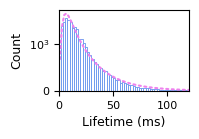

Fit distribution
['3.18e+02', '4.32e+01', '2.52e+03'] ['7.94e+00', '5.18e-01', '3.43e+01'] 0.9947
24786


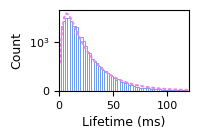

In [11]:
short_dwell_cutoff = 0.

for w in weights:
    
    LifetimeAnalysis()(out_file_path, 
                       fileName_lifetime = "%s_w=%.1e,cutoff=%.1e"%(out_file_name, w, short_dwell_cutoff),
                       fileName_infer = "F1-ATPase_time=6.20e+01,initState=549,index=0_infer_TRY_1dwell,w=%.1e"%w,
                       N_dwell = 3)